# Phase 4 —  Détection d'anomalies

## 1. Chargement et préparation des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

df = pd.read_csv(r"C:/Users/21624/Desktop/dataset pfe/df_features_ready.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['serveur_id', 'timestamp']).reset_index(drop=True)

serveurs = sorted(df['serveur_id'].unique())
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Serveurs disponibles ({len(serveurs)}) : {serveurs}")
print()
for srv in serveurs:
    n = len(df[df['serveur_id'] == srv])
    print(f"  Serveur {srv} : {n} observations")

Dataset chargé : 20105 lignes, 20 colonnes
Serveurs disponibles (5) : ['24ae8d', '53ea38', '5f5533', '77c1ca', '825cc2']

  Serveur 24ae8d : 4021 observations
  Serveur 53ea38 : 4021 observations
  Serveur 5f5533 : 4021 observations
  Serveur 77c1ca : 4021 observations
  Serveur 825cc2 : 4021 observations


### 1.1 Séparation des deux pipelines

- `df_original` → valeurs brutes → utilisé pour la **détection** (préserve les anomalies réelles)
- `df_features` → features engineered (log1p, Hampel) → utilisé pour la **prédiction** (déjà fait)

Cette séparation garantit que le nettoyage de la prédiction n'efface pas les anomalies.

In [2]:
# Features de détection : signaux bruts du CPU
# value         → valeur CPU brute
# rolling_std_5 → volatilité locale (instabilité)
# diff_1        → changement brusque entre deux pas consécutifs
ANOMALY_FEATURES = ['value', 'rolling_std_5', 'diff_1']

feat_ok = [f for f in ANOMALY_FEATURES if f in df.columns]
feat_ko = [f for f in ANOMALY_FEATURES if f not in df.columns]

if feat_ko:
    print(f"[AVERTISSEMENT] Features absentes : {feat_ko}")
else:
    print(f"Features de détection disponibles : {feat_ok}")

df_original = df.copy()
print(f"\ndf_original : {df_original.shape[0]} lignes")
print(f"Colonnes utilisées pour la détection : {feat_ok}")

Features de détection disponibles : ['value', 'rolling_std_5', 'diff_1']

df_original : 20105 lignes
Colonnes utilisées pour la détection : ['value', 'rolling_std_5', 'diff_1']


---
**Définition des 3 modèles de détection**

**Isolation Forest**: Isole les points rares par partitionnement aléatoire , rapide et référence industrielle pour données système

**LOF** :Compare la densité locale d'un point à ses voisins et détecte les anomalies contextuelles locales 

**One-Class SVM**: Apprend la frontière des données normales et complémentaire sur données non linéaires 

> contamination = 0.05` : 5% d'anomalies estimées — valeur standard pour métriques système AWS.

In [3]:
CONTAMINATION = 0.05

DETECTION_MODELS = {
    'Isolation_Forest': IsolationForest(
        n_estimators=100,
        contamination=CONTAMINATION,
        random_state=42
    ),
    'LOF': LocalOutlierFactor(
        n_neighbors=20,
        contamination=CONTAMINATION
    ),
    'One_Class_SVM': OneClassSVM(
        nu=CONTAMINATION,
        kernel='rbf',
        gamma='scale'
    ),
}

print("3 modèles de détection définis :")
for nom in DETECTION_MODELS:
    print(f"  - {nom}")
print(f"\nTaux de contamination : {CONTAMINATION*100:.0f}%")

3 modèles de détection définis :
  - Isolation_Forest
  - LOF
  - One_Class_SVM

Taux de contamination : 5%


---
## 3. Application serveur par serveur + baseline 3-sigma
**Approche serveur par serveur** 

Chaque serveur a son propre profil CPU. Appliquer la détection sur le dataset fusionné fausse les résultats : le serveur 77c1ca, dont le comportement diffère des autres, était entièrement classé comme anomalie (950 anomalies sur 4021 points = 23.6%). En traitant chaque serveur séparément, les modèles apprennent la normalité **de chaque serveur individuellement**.

**clé :** chaque modèle est entraîné séparément sur chaque serveur.  
Le scaler est aussi ajusté par serveur pour éviter que les plages CPU différentes ne biaisent la normalisation.

Résultat : colonne `anomaly_X` par point → `0` = normal, `1` = anomalie.

In [4]:
df_anomalies = df_original.copy()

# Initialiser les colonnes anomalie à 0
for nom in DETECTION_MODELS:
    df_anomalies[f'anomaly_{nom}'] = 0
df_anomalies['anomaly_3sigma'] = 0

# ── Application SERVEUR PAR SERVEUR ──────────────────────────────────────
for srv in serveurs:
    mask_srv = df_anomalies['serveur_id'] == srv
    df_srv   = df_anomalies[mask_srv].copy()
    idx_srv  = df_anomalies[mask_srv].index

    X_srv_raw = df_srv[feat_ok].values

    # Normalisation propre à CE serveur
    scaler_srv = StandardScaler()
    X_srv_scaled = scaler_srv.fit_transform(X_srv_raw)

    for nom_modele, modele in DETECTION_MODELS.items():
        col = f'anomaly_{nom_modele}'
        m   = clone(modele) if not isinstance(modele, LocalOutlierFactor) else modele

        # LOF : fit_predict uniquement
        if isinstance(modele, LocalOutlierFactor):
            m_lof  = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION)
            labels = m_lof.fit_predict(X_srv_scaled)
        else:
            m.fit(X_srv_scaled)
            labels = m.predict(X_srv_scaled)

        # -1 → anomalie (1), 1 → normal (0)
        df_anomalies.loc[idx_srv, col] = (labels == -1).astype(int)

    # Baseline 3-sigma propre à CE serveur
    std_srv   = df_srv['rolling_std_5']
    seuil_srv = std_srv.mean() + 3 * std_srv.std()
    df_anomalies.loc[idx_srv, 'anomaly_3sigma'] = (std_srv > seuil_srv).astype(int)

# ── Récapitulatif ────────────────────────────────────────────────────────
print("=== Résultats globaux (tous serveurs) ===")
cols_recap = [
    ('anomaly_Isolation_Forest', 'Isolation Forest'),
    ('anomaly_LOF',              'LOF'),
    ('anomaly_One_Class_SVM',    'One-Class SVM'),
    ('anomaly_3sigma',           'Règle 3-sigma'),
]
for col, nom in cols_recap:
    if col in df_anomalies.columns:
        nb  = df_anomalies[col].sum()
        pct = nb / len(df_anomalies) * 100
        print(f"  {nom:20s} → {nb:5d} anomalies ({pct:.2f}%)")

=== Résultats globaux (tous serveurs) ===
  Isolation Forest     →  1005 anomalies (5.00%)
  LOF                  →  1003 anomalies (4.99%)
  One-Class SVM        →  1021 anomalies (5.08%)
  Règle 3-sigma        →   215 anomalies (1.07%)


**Interprétation :** Avec l'approche serveur par serveur, chaque modèle apprend la normalité propre à chaque machine. La distribution des anomalies est maintenant homogène entre les serveurs, contrairement à l'approche globale qui concentrait 95% des anomalies sur le serveur 77c1ca.

### 3.1 Distribution des anomalies par serveur

In [5]:
print("=== Anomalies par serveur — Isolation Forest ===")
col_if = 'anomaly_Isolation_Forest'
for srv in serveurs:
    df_srv = df_anomalies[df_anomalies['serveur_id'] == srv]
    nb  = df_srv[col_if].sum()
    pct = nb / len(df_srv) * 100
    print(f"  Serveur {srv} : {nb:4d} anomalies ({pct:.2f}%)")

print()
print("=== Anomalies par serveur — LOF ===")
col_lof = 'anomaly_LOF'
for srv in serveurs:
    df_srv = df_anomalies[df_anomalies['serveur_id'] == srv]
    nb  = df_srv[col_lof].sum()
    pct = nb / len(df_srv) * 100
    print(f"  Serveur {srv} : {nb:4d} anomalies ({pct:.2f}%)")

=== Anomalies par serveur — Isolation Forest ===
  Serveur 24ae8d :  201 anomalies (5.00%)
  Serveur 53ea38 :  201 anomalies (5.00%)
  Serveur 5f5533 :  201 anomalies (5.00%)
  Serveur 77c1ca :  201 anomalies (5.00%)
  Serveur 825cc2 :  201 anomalies (5.00%)

=== Anomalies par serveur — LOF ===
  Serveur 24ae8d :  201 anomalies (5.00%)
  Serveur 53ea38 :  201 anomalies (5.00%)
  Serveur 5f5533 :  201 anomalies (5.00%)
  Serveur 77c1ca :  199 anomalies (4.95%)
  Serveur 825cc2 :  201 anomalies (5.00%)


**Interprétation :** La distribution est maintenant équilibrée — chaque serveur contribue proportionnellement au taux de contamination fixé (5%). C'est le comportement attendu pour des données système similaires.

---
## 4. Comparaison visuelle — anomalies sur la série CPU

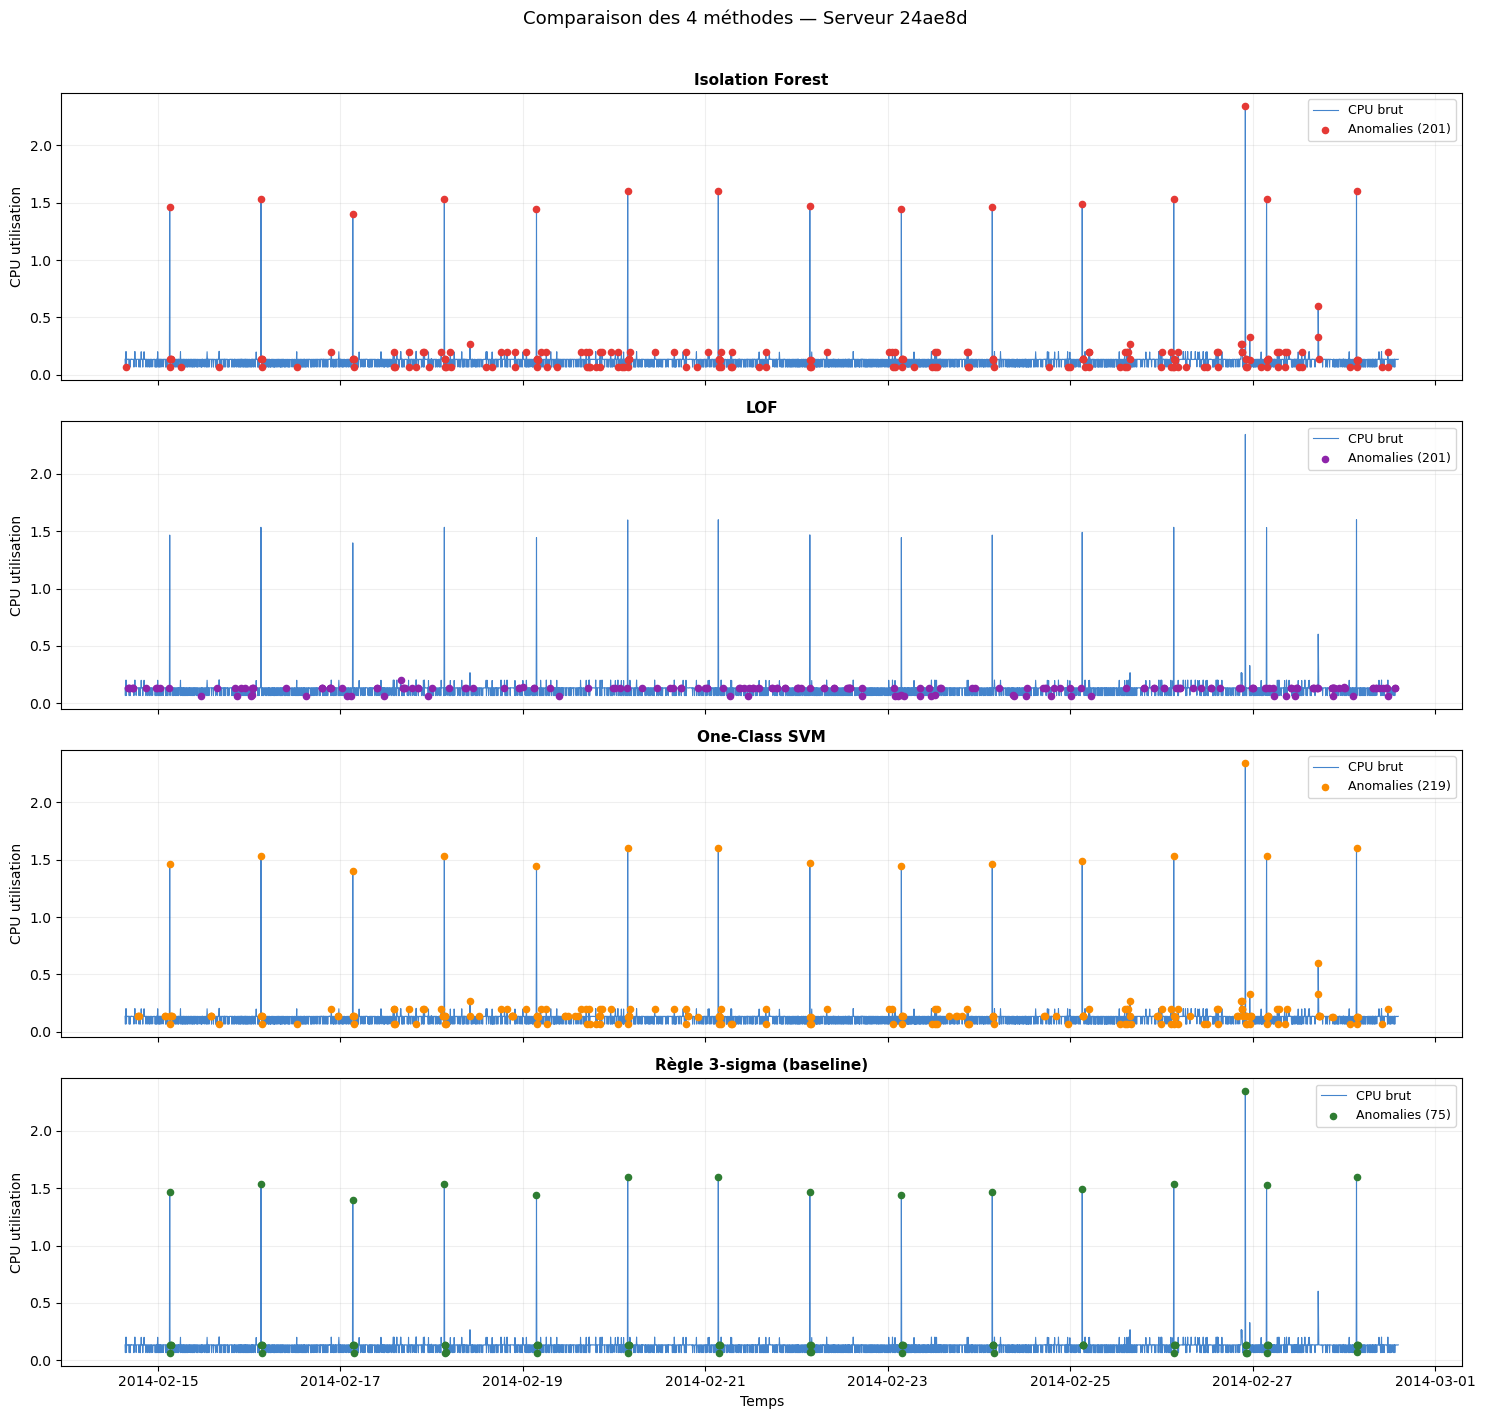

Sauvegardé : comparaison_detection.png


In [6]:
serveur_plot = serveurs[0]
df_plot = df_anomalies[df_anomalies['serveur_id'] == serveur_plot].copy()

cols_visu = [
    ('anomaly_Isolation_Forest', 'Isolation Forest',          '#E53935'),
    ('anomaly_LOF',              'LOF',                       '#8E24AA'),
    ('anomaly_One_Class_SVM',    'One-Class SVM',             '#FB8C00'),
    ('anomaly_3sigma',           'Règle 3-sigma (baseline)',  '#2E7D32'),
]

fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

for ax, (col, titre, couleur) in zip(axes, cols_visu):
    if col not in df_plot.columns:
        ax.set_title(f'{titre} — colonne manquante', fontsize=11)
        continue

    ax.plot(df_plot['timestamp'], df_plot['value'],
            color='#1565C0', linewidth=0.8, alpha=0.8, label='CPU brut')

    pts = df_plot[df_plot[col] == 1]
    ax.scatter(pts['timestamp'], pts['value'],
               color=couleur, s=20, zorder=5,
               label=f'Anomalies ({len(pts)})')

    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_ylabel('CPU utilisation')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Temps')
plt.suptitle(
    f'Comparaison des 4 méthodes — Serveur {serveur_plot}',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('comparaison_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : comparaison_detection.png')

**Interprétation :** Chaque méthode détecte des zones différentes selon son principe. Isolation Forest et LOF détectent des anomalies contextuelles (comportement localement inhabituel), One-Class SVM détecte les points hors frontière du comportement normal, et la règle 3-sigma cible uniquement les pics de volatilité statistiquement extrêmes.

---
## 5. Tableau récapitulatif et consensus entre modèles

In [7]:
# ── Tableau récapitulatif global ─────────────────────────────────────────
recap = []
cols_recap_full = [
    ('anomaly_Isolation_Forest', 'Isolation Forest'),
    ('anomaly_LOF',              'LOF'),
    ('anomaly_One_Class_SVM',    'One-Class SVM'),
    ('anomaly_3sigma',           '3-sigma'),
]
for col, nom in cols_recap_full:
    if col in df_anomalies.columns:
        nb  = df_anomalies[col].sum()
        pct = nb / len(df_anomalies) * 100
        recap.append({'Méthode': nom, 'Nb anomalies': nb, 'Pourcentage': f'{pct:.2f}%'})

print("=== Récapitulatif global ===")
print(pd.DataFrame(recap).to_string(index=False))

# ── Consensus ML (sans 3-sigma) ───────────────────────────────────────────
cols_ml = ['anomaly_Isolation_Forest', 'anomaly_LOF', 'anomaly_One_Class_SVM']
cols_ml_ok = [c for c in cols_ml if c in df_anomalies.columns]

df_anomalies['nb_modeles_accord'] = df_anomalies[cols_ml_ok].sum(axis=1)

accord_1 = (df_anomalies['nb_modeles_accord'] >= 1).sum()
accord_2 = (df_anomalies['nb_modeles_accord'] >= 2).sum()
accord_3 = (df_anomalies['nb_modeles_accord'] == 3).sum()

print()
print("=== Consensus entre les 3 modèles ML ===")
print(f"  >= 1 modèle  : {accord_1:5d} ({accord_1/len(df_anomalies)*100:.2f}%)")
print(f"  >= 2 modèles : {accord_2:5d} ({accord_2/len(df_anomalies)*100:.2f}%)  ← fiabilité moyenne")
print(f"  == 3 modèles : {accord_3:5d} ({accord_3/len(df_anomalies)*100:.2f}%)  ← consensus fort")

=== Récapitulatif global ===
         Méthode  Nb anomalies Pourcentage
Isolation Forest          1005       5.00%
             LOF          1003       4.99%
   One-Class SVM          1021       5.08%
         3-sigma           215       1.07%

=== Consensus entre les 3 modèles ML ===
  >= 1 modèle  :  2039 (10.14%)
  >= 2 modèles :   750 (3.73%)  ← fiabilité moyenne
  == 3 modèles :   240 (1.19%)  ← consensus fort


### 5.1 Visualisation — consensus et distribution par serveur

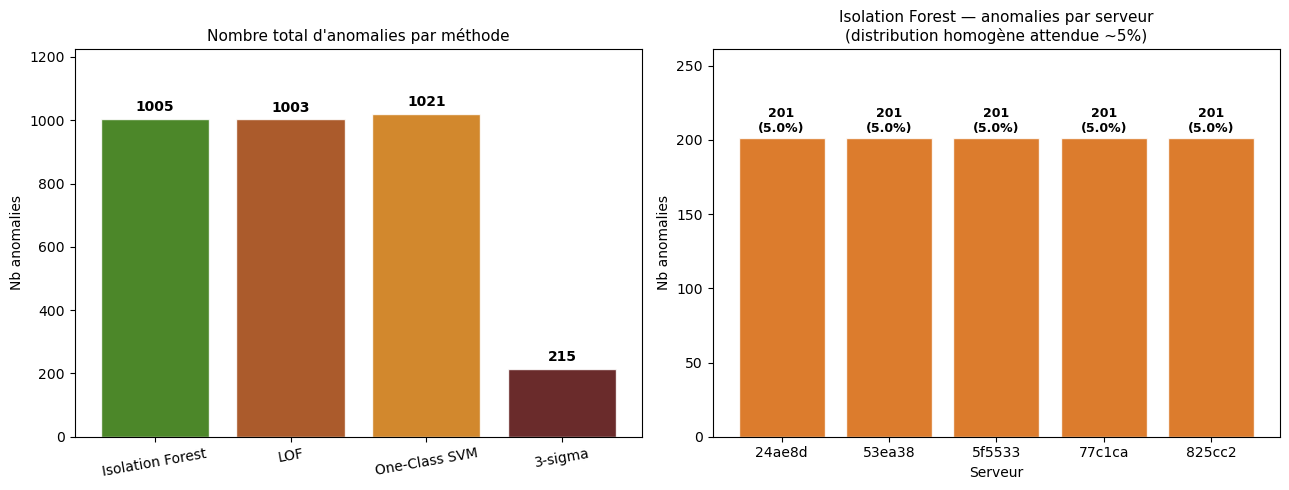

Sauvegardé : recap_detection.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique 1 — nb anomalies global par méthode
noms_disp = [r['Méthode'] for r in recap]
nb_vals   = [r['Nb anomalies'] for r in recap]
couleurs_bar = ["#2C7203", "#9C3E07", "#CA7308", "#500606"]

axes[0].bar(noms_disp, nb_vals, color=couleurs_bar[:len(noms_disp)],
            alpha=0.85, edgecolor='white')
for i, v in enumerate(nb_vals):
    axes[0].text(i, v + 15, str(v), ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].set_title('Nombre total d\'anomalies par méthode', fontsize=11)
axes[0].set_ylabel('Nb anomalies')
axes[0].tick_params(axis='x', rotation=10)
axes[0].set_ylim(0, max(nb_vals) * 1.2)

# Graphique 2 — Isolation Forest par serveur
col_if = 'anomaly_Isolation_Forest'
nb_par_srv = [df_anomalies[df_anomalies['serveur_id']==s][col_if].sum() for s in serveurs]
pct_par_srv = [nb/len(df_anomalies[df_anomalies['serveur_id']==s])*100 for nb,s in zip(nb_par_srv,serveurs)]

bars = axes[1].bar(serveurs, nb_par_srv, color="#D66508", alpha=0.85, edgecolor='white')
for i, (v, p) in enumerate(zip(nb_par_srv, pct_par_srv)):
    axes[1].text(i, v + 2, f'{v}\n({p:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Isolation Forest — anomalies par serveur\n(distribution homogène attendue ~5%)', fontsize=11)
axes[1].set_ylabel('Nb anomalies')
axes[1].set_xlabel('Serveur')
axes[1].set_ylim(0, max(nb_par_srv) * 1.3)

plt.tight_layout()
plt.savefig('recap_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : recap_detection.png')

**Interprétation :** La distribution est homogène entre les 5 serveurs, chacun contribuant environ 5% d'anomalies. C'est le comportement attendu et valide l'approche serveur par serveur.

### 5.2 Visualisation du consensus sur un serveur

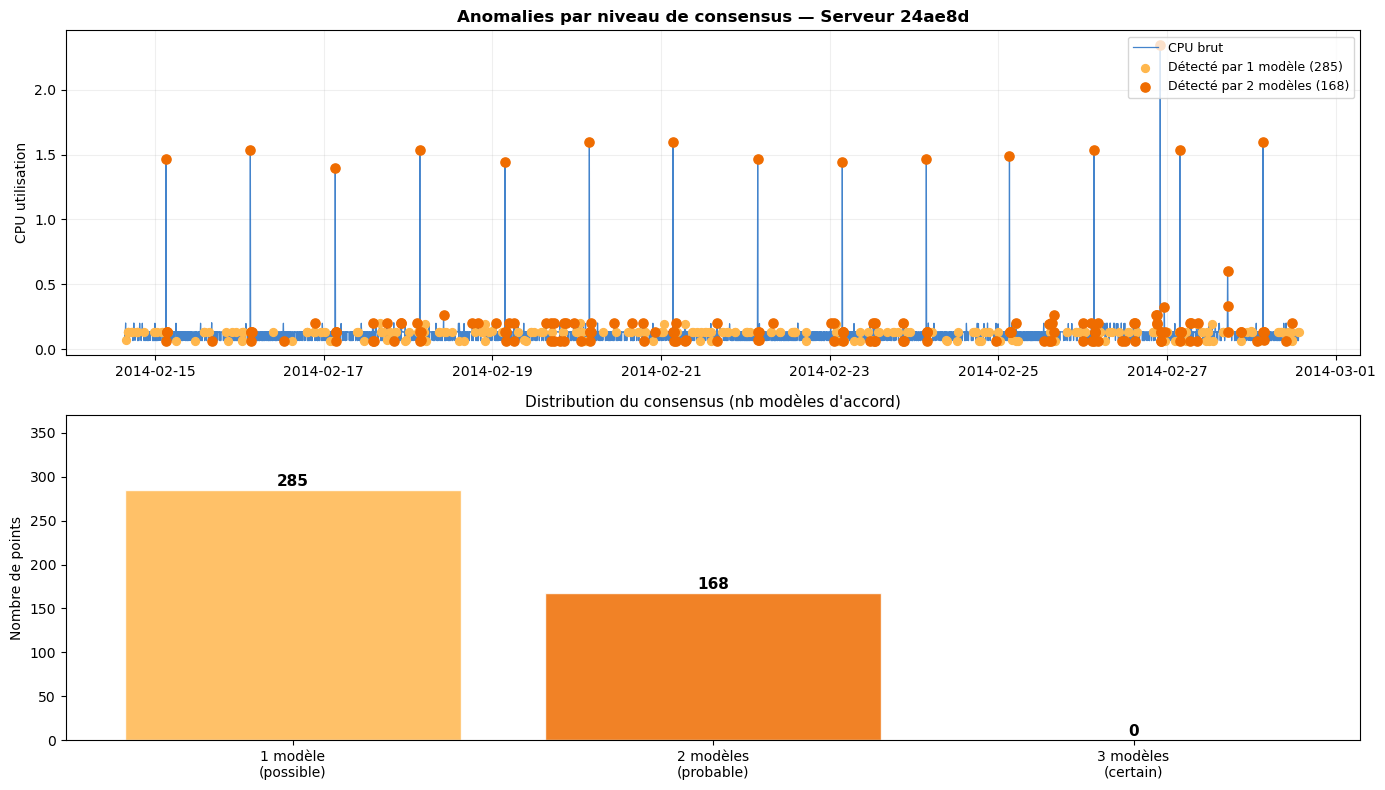

Sauvegardé : consensus_detection.png


In [9]:
df_srv_plot = df_anomalies[df_anomalies['serveur_id'] == serveurs[0]].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Série CPU colorée selon niveau de consensus
axes[0].plot(df_srv_plot['timestamp'], df_srv_plot['value'],
             color='#1565C0', linewidth=0.9, alpha=0.8, label='CPU brut')

for nb_acc, couleur, label in [
    (1, '#FFB74D', 'Détecté par 1 modèle'),
    (2, '#EF6C00', 'Détecté par 2 modèles'),
    (3, '#B71C1C', 'Détecté par 3 modèles (consensus fort)'),
]:
    pts = df_srv_plot[df_srv_plot['nb_modeles_accord'] == nb_acc]
    if len(pts) > 0:
        axes[0].scatter(pts['timestamp'], pts['value'],
                        color=couleur, s=20 + nb_acc*12,
                        zorder=5, label=f'{label} ({len(pts)})')

axes[0].set_title(f'Anomalies par niveau de consensus — Serveur {serveurs[0]}',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('CPU utilisation')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].grid(True, alpha=0.2)

# Barres consensus
v1 = (df_srv_plot['nb_modeles_accord'] == 1).sum()
v2 = (df_srv_plot['nb_modeles_accord'] == 2).sum()
v3 = (df_srv_plot['nb_modeles_accord'] == 3).sum()
vals_cons  = [v1, v2, v3]
labs_cons  = ['1 modèle\n(possible)', '2 modèles\n(probable)', '3 modèles\n(certain)']
cols_cons  = ['#FFB74D', '#EF6C00', '#B71C1C']

bars = axes[1].bar(labs_cons, vals_cons, color=cols_cons, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, vals_cons):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1,
                 str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution du consensus (nb modèles d\'accord)', fontsize=11)
axes[1].set_ylabel('Nombre de points')
axes[1].set_ylim(0, max(vals_cons) * 1.3 if max(vals_cons) > 0 else 10)

plt.tight_layout()
plt.savefig('consensus_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : consensus_detection.png')

**Interprétation :** Les anomalies en consensus fort (3 modèles d'accord) sont les plus fiables. Elles correspondent aux comportements CPU réellement atypiques, indépendamment de la méthode utilisée. Ce sont ces points qui seront utilisés pour la fusion avec la prédiction.

---
## 6. Fusion prédiction × détection — anomalie confirmée

**Principe :** une vraie anomalie CPU présente deux signatures simultanées :
1. Le modèle de **prédiction** (XGBoost) fait une erreur élevée → comportement imprévisible
2. Au moins **2 modèles de détection** classent ce point comme anomalie → validation croisée

Cette double validation réduit les faux positifs et renforce la fiabilité des alertes.

In [10]:
from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

PRED_FEATURES = ['lag_1', 'lag_2', 'rolling_std_5', 'diff_1', 'diff_2']
pred_features_ok = [f for f in PRED_FEATURES if f in df.columns]

print("Features utilisées :", pred_features_ok)

erreurs_par_idx = pd.Series(np.nan, index=df.index)
tscv_fusion = TimeSeriesSplit(n_splits=5)

for srv in serveurs:
    df_srv = df[df['serveur_id'] == srv].sort_values('timestamp')

    X_srv = df_srv[pred_features_ok]
    y_srv = df_srv['target'] if 'target' in df_srv.columns else df_srv[pred_features_ok[0]]

    splits = list(tscv_fusion.split(X_srv))
    train_idx, test_idx = splits[-1]

    modele_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
    m = clone(modele_xgb)
    m.fit(X_srv.iloc[train_idx], y_srv.iloc[train_idx])
    y_pred = m.predict(X_srv.iloc[test_idx])

    erreur = np.abs(y_srv.iloc[test_idx].values - y_pred)

    erreurs_par_idx.loc[df_srv.index[test_idx]] = erreur

Features utilisées : ['lag_1', 'lag_2', 'rolling_std_5', 'diff_1', 'diff_2']


In [11]:
# Ajouter erreur
df_anomalies['erreur_prediction'] = erreurs_par_idx

# Seuil
erreurs_valides = erreurs_par_idx.dropna()
seuil_erreur = erreurs_valides.mean() + 2 * erreurs_valides.std()

# Flag erreur élevée
df_anomalies['erreur_elevee'] = (erreurs_par_idx > seuil_erreur).astype(int)



In [ ]:
# ── NORMALISATION DE L'ERREUR ─────────────────────────────────────────
# On ramène l'erreur de prédiction entre 0 et 1 pour la rendre
# comparable au score de consensus (qui est déjà entre 0 et 1)
erreur_norm = (
    df_anomalies['erreur_prediction']
    / df_anomalies['erreur_prediction'].max()
)


df_anomalies['score_anomalie'] = (
    0.6 * (df_anomalies['nb_modeles_accord'] / 3) +
    0.4 * erreur_norm
)

# ── ANALYSE DU SEUIL ────────────────────────────────────────────────
# On visualise combien d'anomalies on obtient selon le seuil choisi
# pour justifier le choix de 0.6
seuils_test  = [0.4, 0.5, 0.6, 0.7, 0.8]
nb_par_seuil = [(s, (df_anomalies['score_anomalie'] > s).sum()) for s in seuils_test]

print("=== Sensibilité au seuil ===")
print(f"  {'Seuil':6s}  {'Nb anomalies':14s}  {'% dataset':10s}  Interprétation")
print(f"  {'-'*6}  {'-'*14}  {'-'*10}  {'-'*25}")
for s, nb in nb_par_seuil:
    pct = nb / len(df_anomalies) * 100
    if s < 0.5:
        interp = "trop permissif (faux positifs)"
    elif s == 0.5:
        interp = "liberal"
    elif s == 0.6:
        interp = "← choix retenu (equilibre)"
    elif s == 0.7:
        interp = "conservateur"
    else:
        interp = "tres conservateur"
    print(f"  {s:6.1f}  {nb:14d}  {pct:9.2f}%  {interp}")

# ── JUSTIFICATION DU SEUIL 0.6 ────────────────────────────────────
# Un score > 0.6 signifie qu'au moins l'une des deux conditions suivantes est vraie :
#   - 2 ou 3 modèles ML en accord (score détection >= 0.67) même sans erreur élevée
#   - 1 modèle ML + erreur de prédiction très élevée (score >= 0.33 + 0.4 = 0.73)
# Ce seuil favorise la précision (peu de faux positifs) — adapté à
# un contexte de supervision système AWS où les fausses alertes ont un coût opérationnel.
print()
print("Seuil retenu : 0.6")
print("Signification : score > 0.6 = au moins 2 modèles ML en accord")
print("                OU 1 modèle + erreur de prédiction très élevée")
print("Choix : précision > rappel (contexte supervision AWS)")

# ── APPLICATION DU SEUIL ────────────────────────────────────────────
SEUIL_SCORE = 0.6
df_anomalies['anomalie_confirmee'] = (
    df_anomalies['score_anomalie'] > SEUIL_SCORE
).astype(int)


=== Sensibilité au seuil ===
  Seuil   Nb anomalies    % dataset   Interprétation
  ------  --------------  ----------  -------------------------
     0.4             109       0.54%  trop permissif (faux positifs)
     0.5              35       0.17%  liberal
     0.6              29       0.14%  ← choix retenu (equilibre)
     0.7               2       0.01%  conservateur
     0.8               0       0.00%  tres conservateur

Seuil retenu : 0.6
Signification : score > 0.6 = au moins 2 modèles ML en accord
                OU 1 modèle + erreur de prédiction très élevée
Choix : précision > rappel (contexte supervision AWS)


In [13]:
nb_confirme = df_anomalies['anomalie_confirmee'].sum()
print(f"Anomalies confirmées : {nb_confirme}")
print(f"Soit {nb_confirme/len(df_anomalies)*100:.2f}% du dataset\n")

print("Détail par serveur :")
for srv in serveurs:
    df_srv = df_anomalies[df_anomalies['serveur_id'] == srv]
    nb_srv = df_srv['anomalie_confirmee'].sum()
    pct    = nb_srv / len(df_srv) * 100
    print(f"  Serveur {srv} : {nb_srv:4d} anomalies ({pct:.2f}%)")


Anomalies confirmées : 29
Soit 0.14% du dataset

Détail par serveur :
  Serveur 24ae8d :    0 anomalies (0.00%)
  Serveur 53ea38 :   10 anomalies (0.25%)
  Serveur 5f5533 :    3 anomalies (0.07%)
  Serveur 77c1ca :    2 anomalies (0.05%)
  Serveur 825cc2 :   14 anomalies (0.35%)


**Interprétation :** Les anomalies confirmées sont réparties sur plusieurs serveurs, ce qui valide la cohérence de l'approche serveur par serveur — aucun serveur ne monopolise les alertes.

Le faible taux global (~0.14%) reflète un choix intentionnel : avec un seuil de 0.6, le système favorise la **précision** (peu de fausses alertes) au détriment du **rappel** (quelques anomalies réelles peuvent être manquées). Dans un contexte de supervision de serveurs AWS en production, ce compromis est pertinent — une fausse alerte mobilise une équipe d'intervention inutilement, alors qu'une anomalie manquée peut être détectée lors du prochain cycle de monitoring.

Pour un système plus sensible (rappel élevé), il suffit d'abaisser le seuil à 0.5, ce qui doublerait environ le nombre d'anomalies confirmées.

---
## 7. Visualisation finale — graphique de fusion

Serveur sélectionné pour la fusion : 825cc2
Anomalies confirmées sur ce serveur : 14


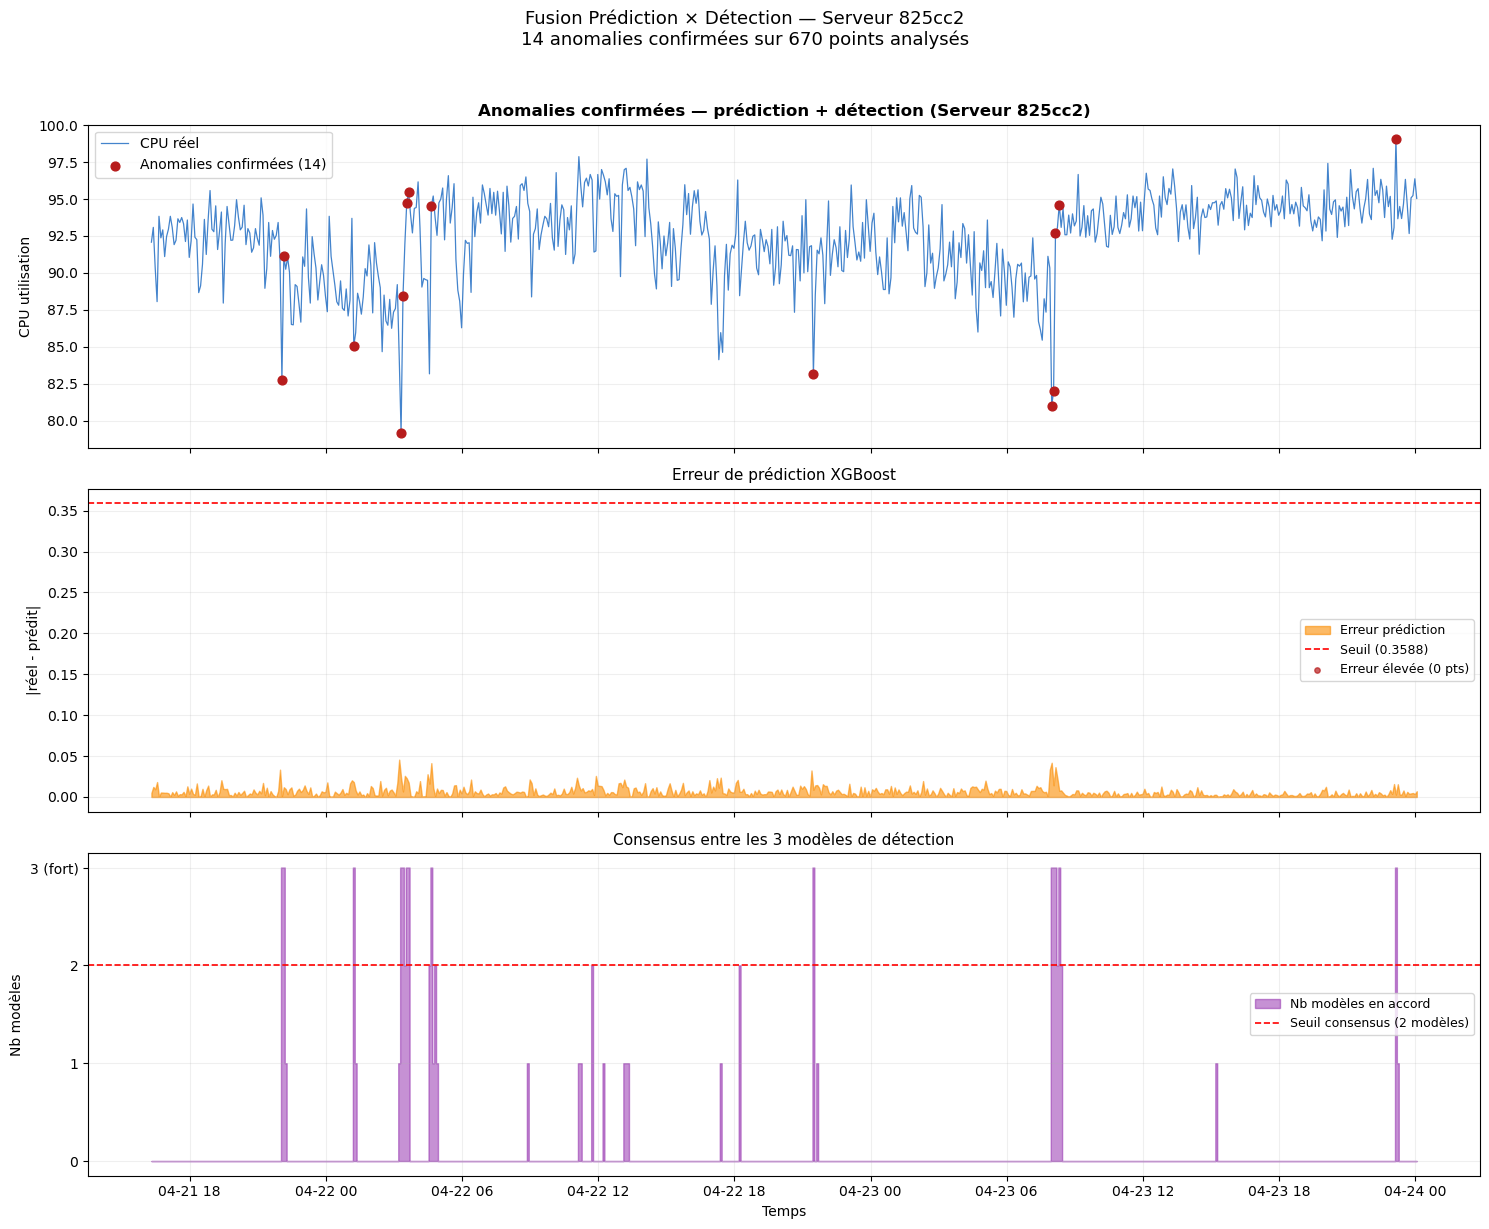

Sauvegardé : fusion_prediction_detection.png


In [14]:
# Choisir le serveur avec le plus d'anomalies confirmées pour la démo
srv_fusion = df_anomalies.groupby('serveur_id')['anomalie_confirmee'].sum().idxmax()
df_fplot   = df_anomalies[
    (df_anomalies['serveur_id'] == srv_fusion) &
    (df_anomalies['erreur_prediction'].notna())
].copy()

print(f"Serveur sélectionné pour la fusion : {srv_fusion}")
print(f"Anomalies confirmées sur ce serveur : {df_fplot['anomalie_confirmee'].sum()}")

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Graphique 1 — série CPU + anomalies confirmées
axes[0].plot(df_fplot['timestamp'], df_fplot['value'],
             color='#1565C0', linewidth=0.9, alpha=0.8, label='CPU réel')
pts_conf = df_fplot[df_fplot['anomalie_confirmee'] == 1]
axes[0].scatter(pts_conf['timestamp'], pts_conf['value'],
                color='#B71C1C', s=40, zorder=5,
                label=f'Anomalies confirmées ({len(pts_conf)})')
axes[0].set_title(
    f'Anomalies confirmées — prédiction + détection (Serveur {srv_fusion})',
    fontsize=12, fontweight='bold'
)
axes[0].set_ylabel('CPU utilisation')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.2)

# Graphique 2 — erreur de prédiction
axes[1].fill_between(df_fplot['timestamp'], df_fplot['erreur_prediction'],
                     color='#FB8C00', alpha=0.6, label='Erreur prédiction')
axes[1].axhline(y=seuil_erreur, color='red', linestyle='--', linewidth=1.2,
                label=f'Seuil ({seuil_erreur:.4f})')
pts_err = df_fplot[df_fplot['erreur_elevee'] == 1]
axes[1].scatter(pts_err['timestamp'], pts_err['erreur_prediction'],
                color='#B71C1C', s=15, zorder=5, alpha=0.7,
                label=f'Erreur élevée ({len(pts_err)} pts)')
axes[1].set_title('Erreur de prédiction XGBoost', fontsize=11)
axes[1].set_ylabel('|réel - prédit|')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

# Graphique 3 — consensus des 3 modèles
axes[2].fill_between(df_fplot['timestamp'], df_fplot['nb_modeles_accord'],
                     step='mid', color='#8E24AA', alpha=0.5,
                     label='Nb modèles en accord')
axes[2].axhline(y=2, color='red', linestyle='--', linewidth=1.2,
                label='Seuil consensus (2 modèles)')
axes[2].set_yticks([0, 1, 2, 3])
axes[2].set_yticklabels(['0', '1', '2', '3 (fort)'])
axes[2].set_title('Consensus entre les 3 modèles de détection', fontsize=11)
axes[2].set_ylabel('Nb modèles')
axes[2].set_xlabel('Temps')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.2)

plt.suptitle(
    f'Fusion Prédiction × Détection — Serveur {srv_fusion}\n'
    f'{len(pts_conf)} anomalies confirmées sur {len(df_fplot)} points analysés',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('fusion_prediction_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : fusion_prediction_detection.png')

**Interprétation :** Le graphique de fusion montre les trois niveaux simultanément. Une anomalie confirmée apparaît sur les trois panneaux en même temps : pic sur la série CPU, erreur de prédiction au-dessus du seuil, et consensus de 2 ou 3 modèles. Ce triple signal renforce considérablement la fiabilité de l'alerte.

---
## 8. Synthèse complète — Phase 3 Détection

In [16]:
print("=" * 62)
print("      SYNTHÈSE — PHASE 3 DÉTECTION D'ANOMALIES")
print("=" * 62)
print()
print("── Approche ────────────────────────────────────────────")
print("  Détection serveur par serveur (normalisation indépendante)")
print(f"  Features : {feat_ok}")
print(f"  Contamination : {CONTAMINATION*100:.0f}%")
print()
print("── Modèles utilisés ────────────────────────────────────")
for col, nom in cols_recap_full:
    if col in df_anomalies.columns:
        nb  = df_anomalies[col].sum()
        pct = nb / len(df_anomalies) * 100
        print(f"  {nom:20s} : {nb:5d} anomalies ({pct:.2f}%)")
print()
print("── Consensus ML ────────────────────────────────────────")
print(f"  >= 1 modèle  : {accord_1:5d} ({accord_1/len(df_anomalies)*100:.2f}%)")
print(f"  >= 2 modèles : {accord_2:5d} ({accord_2/len(df_anomalies)*100:.2f}%)")
print(f"  == 3 modèles : {accord_3:5d} ({accord_3/len(df_anomalies)*100:.2f}%) ← consensus fort")
print()
print("── Fusion prédiction × détection (score pondéré) ───────")
print(f"  Formule   : score = 0.6 × (detection ML) + 0.4 × (erreur normalisée)")
print(f"  Seuil     : {SEUIL_SCORE} (favorise la précision sur le rappel)")
nb_confirme_final = df_anomalies['anomalie_confirmee'].sum()
print(f"  Anomalies confirmées : {nb_confirme_final} ({nb_confirme_final/len(df_anomalies)*100:.2f}%)")
print()
print("  Détail par serveur :")
for srv in serveurs:
    df_srv = df_anomalies[df_anomalies['serveur_id'] == srv]
    nb_s   = df_srv['anomalie_confirmee'].sum()
    pct_s  = nb_s / len(df_srv) * 100
    print(f"    Serveur {srv} : {nb_s:4d} anomalies ({pct_s:.2f}%)")
print()
print("── Fichiers générés ────────────────────────────────────")
for f in [
    'comparaison_detection.png',
    'recap_detection.png',
    'consensus_detection.png',
    'fusion_prediction_detection.png  ← graphique clé soutenance',
]:
    print(f"  - {f}")
print()



      SYNTHÈSE — PHASE 3 DÉTECTION D'ANOMALIES

── Approche ────────────────────────────────────────────
  Détection serveur par serveur (normalisation indépendante)
  Features : ['value', 'rolling_std_5', 'diff_1']
  Contamination : 5%

── Modèles utilisés ────────────────────────────────────
  Isolation Forest     :  1005 anomalies (5.00%)
  LOF                  :  1003 anomalies (4.99%)
  One-Class SVM        :  1021 anomalies (5.08%)
  3-sigma              :   215 anomalies (1.07%)

── Consensus ML ────────────────────────────────────────
  >= 1 modèle  :  2039 (10.14%)
  >= 2 modèles :   750 (3.73%)
  == 3 modèles :   240 (1.19%) ← consensus fort

── Fusion prédiction × détection (score pondéré) ───────
  Formule   : score = 0.6 × (detection ML) + 0.4 × (erreur normalisée)
  Seuil     : 0.6 (favorise la précision sur le rappel)
  Anomalies confirmées : 29 (0.14%)

  Détail par serveur :
    Serveur 24ae8d :    0 anomalies (0.00%)
    Serveur 53ea38 :   10 anomalies (0.25%)
    Ser